# Task 2 - Colapso de modo inducido y estimacion de JSD

Segunda parte de la HDT2. Se reutiliza la arquitectura y el dataset de Task 1
(mismas clases `Generator`/`Discriminator`, mismos 898 sprites de Pokemon).

- **Task 2.1:** se desbalancea el entrenamiento (5 pasos de D por 1 de G,
  20 epocas) para inducir modo colapso a proposito.
- **Task 2.2:** se estima Jensen-Shannon divergence a partir de los registros
  del entrenamiento base de Task 1 (`outputs/task1/history.csv`), sin volver
  a entrenar nada.


## 1. Imports, configuracion y reproducibilidad

In [1]:
from pathlib import Path
import csv
import json
import os
import random
import sys
import time

import matplotlib
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# mismos parametros fijos que task 1, porque el enunciado pide reutilizar
# la arquitectura tal cual
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64
BATCH_SIZE = 32
LEARNING_RATE = 2e-4
BETAS = (0.5, 0.999)
SEED = 42

# parametros nuevos, especificos del experimento de colapso de task 2.1
NUM_EPOCHS_COLLAPSE = 20
D_STEPS_PER_G_STEP = 5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 4))
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'pokemon'

# task1 ya dejo su evidencia en outputs/task1, aqui se lee de ahi sin tocarla
TASK1_DIR = ROOT / 'outputs' / 'task1'

# outputs propios de task 2
OUTPUT_DIR = ROOT / 'outputs' / 'task2'
GRID_DIR = OUTPUT_DIR / 'grids'
GRID_DIR.mkdir(parents=True, exist_ok=True)

print(f'Python: {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'Dispositivo: {DEVICE}')
print(f'Datos: {DATA_DIR}')
print(f'Outputs task1 (lectura): {TASK1_DIR}')
print(f'Outputs task2 (escritura): {OUTPUT_DIR}')

Python: 3.13.6
PyTorch: 2.13.0+cpu
Dispositivo: cpu
Datos: C:\Users\djlop\OneDrive\DIEGO\UVG\2026\segundo semestre\COMPARTIDOS\Deep-Learning\data\pokemon
Outputs task1 (lectura): C:\Users\djlop\OneDrive\DIEGO\UVG\2026\segundo semestre\COMPARTIDOS\Deep-Learning\outputs\task1
Outputs task2 (escritura): C:\Users\djlop\OneDrive\DIEGO\UVG\2026\segundo semestre\COMPARTIDOS\Deep-Learning\outputs\task2


## 2. Dataset

Mismo dataset y mismo preprocesamiento que Task 1: imagenes en RGB 64x64,
normalizadas a `[-1, 1]` para que coincidan con el rango de `Tanh` del
generador.

In [2]:
class PokemonDataset(Dataset):
    def __init__(self, root: Path):
        self.files = sorted(Path(root).glob('*.png'))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        path = self.files[index]
        with Image.open(path) as image:
            image = image.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.Resampling.NEAREST)
            array = np.asarray(image, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array).permute(2, 0, 1)
        return tensor.mul(2.0).sub(1.0)

dataset = PokemonDataset(DATA_DIR)
if len(dataset) == 0:
    dataloader = None
    print('No hay sprites. Ejecute: python scripts/download_pokemon.py')
else:
    dataloader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True
    )
    # drop_last=True aqui porque el loop 5:1 de 2.1 necesita bloques exactos
    # de 5 batches reales consecutivos; un batch final mas chico rompe ese
    # conteo, asi que se descarta explicitamente (no se trunca en silencio)
    sample_batch = next(iter(dataloader))
    assert sample_batch.ndim == 4 and sample_batch.shape[1:] == (3, 64, 64)
    assert -1.0 <= sample_batch.min() <= sample_batch.max() <= 1.0
    print(f'Imagenes: {len(dataset)} | batch: {tuple(sample_batch.shape)}')
    print(f'Batches por epoca (drop_last=True): {len(dataloader)}')

Imagenes: 898 | batch: (32, 3, 64, 64)
Batches por epoca (drop_last=True): 28


## 3. Arquitectura (identica a Task 1)

Se copian `Generator`, `Discriminator` y `weights_init` tal cual de
`task1.ipynb`, porque el enunciado exige reutilizar la misma arquitectura
para que el experimento de colapso sea comparable con el entrenamiento
base.

In [3]:
def weights_init(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0.0)


class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, channels=IMG_CHANNELS, features=FEATURES_G):
        super().__init__()
        self.net = nn.Sequential(
            self._block(z_dim, features * 8, 4, 1, 0),
            self._block(features * 8, features * 4, 4, 2, 1),
            self._block(features * 4, features * 2, 4, 2, 1),
            self._block(features * 2, features, 4, 2, 1),
            nn.ConvTranspose2d(features, channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    @staticmethod
    def _block(in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, noise):
        return self.net(noise)


class Discriminator(nn.Module):
    def __init__(self, channels=IMG_CHANNELS, features=FEATURES_D):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features, features * 2),
            self._block(features * 2, features * 4),
            self._block(features * 4, features * 8),
            nn.Conv2d(features * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    @staticmethod
    def _block(in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, image):
        return self.net(image).view(-1)


def save_grid(images, destination, title=None, show=False):
    # desnormaliza de [-1,1] a [0,1] para poder graficar con imshow
    images = images.detach().cpu().clamp(-1, 1).add(1).div(2)
    figure, axes = plt.subplots(4, 4, figsize=(8, 8))
    for axis, image in zip(axes.flat, images[:16]):
        axis.imshow(image.permute(1, 2, 0).numpy())
        axis.axis('off')
    if title:
        figure.suptitle(title)
    figure.tight_layout()
    figure.savefig(destination, dpi=150, bbox_inches='tight')
    if show:
        plt.show()
    plt.close(figure)

In [4]:
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
generator.apply(weights_init)
discriminator.apply(weights_init)

test_noise = torch.randn(4, Z_DIM, 1, 1, device=DEVICE)
test_images = torch.randn(4, 3, 64, 64, device=DEVICE)
assert generator(test_noise).shape == (4, 3, 64, 64), 'Forma del generador incorrecta'
assert discriminator(test_images).shape == (4,), 'Forma del discriminador incorrecta'

g_parameters = sum(parameter.numel() for parameter in generator.parameters())
d_parameters = sum(parameter.numel() for parameter in discriminator.parameters())
print(f'Pruebas de forma correctas | G: {g_parameters:,} params | D: {d_parameters:,} params')

Pruebas de forma correctas | G: 3,576,704 params | D: 2,765,568 params


## 4. Task 2.1 - Colapso de modo inducido

Se rompe el balance 1:1 del entrenamiento adversarial: por cada paso de G se
dan **5 pasos de D**, cada uno con un batch real distinto (5 batches
consecutivos del dataloader). La idea es que D se vuelva demasiado fuerte
demasiado rapido y deje de darle a G una senal de gradiente util, forzando
el colapso de modo.

Se entrena por 20 epocas (no 50, para que el colapso sea rapido de observar).
Ademas de `loss_G`/`loss_D`, se registra la **norma L2 del gradiente de G**
en cada epoca (promedio de las normas del ultimo paso de G de cada bloque),
como evidencia empirica para la pregunta a).

In [5]:
def gradient_norm(model):
    # norma L2 de todos los gradientes de un modelo, concatenados.
    # sirve para ver que tan "vivo" esta el gradiente de G paso a paso.
    total = 0.0
    for parameter in model.parameters():
        if parameter.grad is not None:
            total += parameter.grad.data.norm(2).item() ** 2
    return total ** 0.5


def train_collapse(generator, discriminator, dataloader, epochs, d_steps):
    criterion = nn.BCELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
    optimizer_d = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)
    fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=DEVICE)
    history = []

    batch_iterator_len = len(dataloader)
    # con drop_last=True cada batch tiene BATCH_SIZE parejo, asi que se puede
    # agrupar el dataloader en bloques exactos de d_steps sin sobrantes raros
    blocks_per_epoch = batch_iterator_len // d_steps
    used_batches = blocks_per_epoch * d_steps
    leftover = batch_iterator_len - used_batches
    if leftover:
        print(
            f'Aviso: se descartan {leftover} batches sueltos por epoca que no '
            f'completan un bloque de {d_steps} pasos de D.'
        )

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        generator.train()
        discriminator.train()
        total_g = 0.0
        total_d = 0.0
        total_grad_norm_g = 0.0
        seen_g_steps = 0
        seen_d_batches = 0

        data_iter = iter(dataloader)
        for _ in range(blocks_per_epoch):
            # bloque de 5 pasos de D con 5 batches reales distintos
            for _ in range(d_steps):
                real_images = next(data_iter).to(DEVICE)
                batch_size = real_images.size(0)
                real_labels = torch.ones(batch_size, device=DEVICE)
                fake_labels = torch.zeros(batch_size, device=DEVICE)

                optimizer_d.zero_grad(set_to_none=True)
                noise = torch.randn(batch_size, Z_DIM, 1, 1, device=DEVICE)
                fake_images = generator(noise)
                loss_d_real = criterion(discriminator(real_images), real_labels)
                loss_d_fake = criterion(discriminator(fake_images.detach()), fake_labels)
                loss_d = loss_d_real + loss_d_fake
                loss_d.backward()
                optimizer_d.step()

                total_d += loss_d.item() * batch_size
                seen_d_batches += batch_size

            # 1 paso de G, con un batch de ruido nuevo (objetivo no saturante)
            optimizer_g.zero_grad(set_to_none=True)
            new_noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1, device=DEVICE)
            new_fake_images = generator(new_noise)
            g_labels = torch.ones(BATCH_SIZE, device=DEVICE)
            loss_g = criterion(discriminator(new_fake_images), g_labels)
            loss_g.backward()
            total_grad_norm_g += gradient_norm(generator)
            optimizer_g.step()

            total_g += loss_g.item() * BATCH_SIZE
            seen_g_steps += BATCH_SIZE

        epoch_result = {
            'epoch': epoch,
            'loss_G': total_g / seen_g_steps,
            'loss_D': total_d / seen_d_batches,
            'grad_norm_G': total_grad_norm_g / blocks_per_epoch,
        }
        history.append(epoch_result)

        generator.eval()
        with torch.no_grad():
            fixed_images = generator(fixed_noise)
        save_grid(
            fixed_images, GRID_DIR / f'epoch_{epoch:03d}.png', title=f'Epoca {epoch} (colapso)'
        )
        elapsed = time.perf_counter() - started
        print(
            f'Epoca {epoch:02d}/{epochs} | D: {epoch_result["loss_D"]:.4f} | '
            f'G: {epoch_result["loss_G"]:.4f} | '
            f'||grad_G||: {epoch_result["grad_norm_G"]:.6f} | {elapsed:.1f}s'
        )

    return history, fixed_noise

In [6]:
# False carga resultados existentes; True vuelve a entrenar las 20 epocas de colapso.
RUN_COLLAPSE_TRAINING = False
collapse_history = None
collapse_fixed_noise = None

collapse_final_files = [
    OUTPUT_DIR / 'collapse_history.csv',
    OUTPUT_DIR / 'collapse_grid.png',
    OUTPUT_DIR / 'generator_collapse_final.pt',
    OUTPUT_DIR / 'discriminator_collapse_final.pt',
]

def write_collapse_history(history, destination):
    with destination.open('w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)


def read_collapse_history(destination):
    with destination.open('r', newline='', encoding='utf-8') as file:
        return [
            {
                'epoch': int(row['epoch']),
                'loss_G': float(row['loss_G']),
                'loss_D': float(row['loss_D']),
                'grad_norm_G': float(row['grad_norm_G']),
            }
            for row in csv.DictReader(file)
        ]


if RUN_COLLAPSE_TRAINING:
    if dataloader is None:
        raise RuntimeError('Primero descargue los sprites con scripts/download_pokemon.py')
    if len(dataset) != 898:
        raise RuntimeError(f'Se esperaban 898 sprites y se encontraron {len(dataset)}')
    collapse_history, collapse_fixed_noise = train_collapse(
        generator, discriminator, dataloader,
        epochs=NUM_EPOCHS_COLLAPSE, d_steps=D_STEPS_PER_G_STEP,
    )
    write_collapse_history(collapse_history, OUTPUT_DIR / 'collapse_history.csv')
    torch.save(collapse_fixed_noise.detach().cpu(), OUTPUT_DIR / 'collapse_fixed_noise.pt')
    # se guardan los pesos entrenados de este experimento para poder recargar
    # el mismo G/D exactos si se re-ejecuta el notebook sin re-entrenar
    torch.save(generator.state_dict(), OUTPUT_DIR / 'generator_collapse_final.pt')
    torch.save(discriminator.state_dict(), OUTPUT_DIR / 'discriminator_collapse_final.pt')
elif all(path.exists() for path in collapse_final_files):
    collapse_history = read_collapse_history(OUTPUT_DIR / 'collapse_history.csv')
    generator.load_state_dict(
        torch.load(OUTPUT_DIR / 'generator_collapse_final.pt', map_location=DEVICE, weights_only=True)
    )
    discriminator.load_state_dict(
        torch.load(OUTPUT_DIR / 'discriminator_collapse_final.pt', map_location=DEVICE, weights_only=True)
    )
    print(f'Resultados existentes cargados: {len(collapse_history)} epocas.')
else:
    print('Use RUN_COLLAPSE_TRAINING=True para iniciar las 20 epocas del experimento de colapso.')

Resultados existentes cargados: 20 epocas.


### Grilla final y metrica de diversidad

Se genera la grilla final de 16 imagenes con el `fixed_noise` del
entrenamiento de colapso, y se calcula una metrica cuantitativa simple de
diversidad (desviacion estandar promedio por pixel entre las 16 muestras) para
respaldar numericamente si hubo baja diversidad, ademas de la inspeccion
visual. Se calcula la misma metrica sobre la grilla final de Task 1 para
poder comparar.

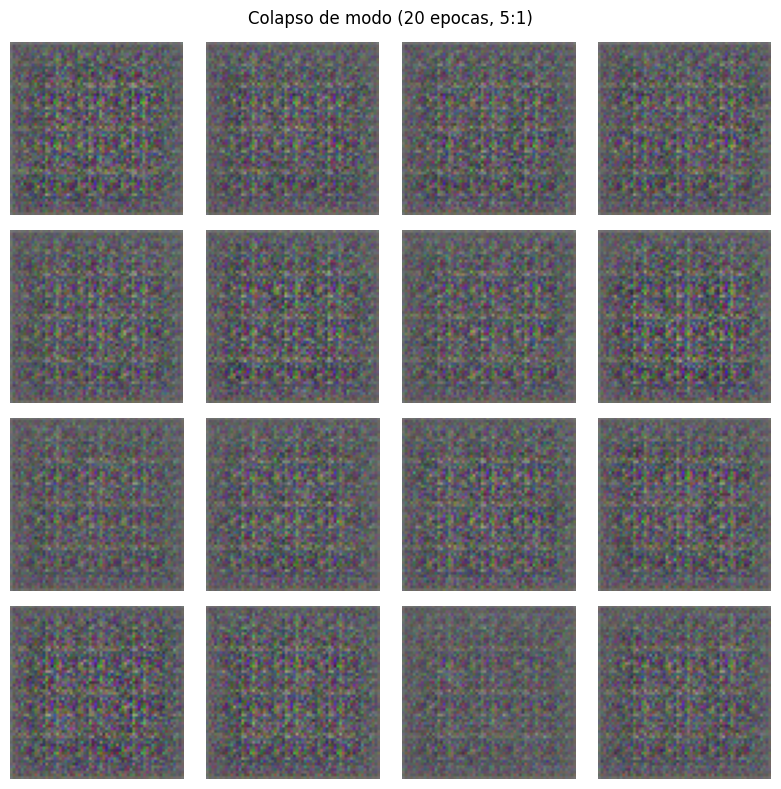

{
  "final_loss_G": 36.91478042602539,
  "final_loss_D": 3.609915514516615e-05,
  "mean_D_of_G_z": 1.1334038390486967e-05,
  "diversity_metric": 0.04487128555774689,
  "grad_norm_G_final": 0.6647215061674099,
  "task1_final_grid_diversity_reference": 0.4097561538219452
}


In [7]:
def diversity_metric(images):
    # images: tensor (N, C, H, W) ya desnormalizado a [0,1]
    # se mide cuanto varian los pixeles entre las N muestras: si G colapsa
    # a pocas salidas, la desviacion estandar entre muestras cae mucho
    return images.std(dim=0).mean().item()


def mean_discriminator_score(discriminator, images):
    discriminator.eval()
    with torch.no_grad():
        scores = discriminator(images)
    return scores.mean().item()


if collapse_history is not None:
    if collapse_fixed_noise is None:
        collapse_fixed_noise = torch.load(
            OUTPUT_DIR / 'collapse_fixed_noise.pt', map_location=DEVICE, weights_only=True
        )
    generator.eval()
    with torch.no_grad():
        collapse_final_images = generator(collapse_fixed_noise)
    save_grid(collapse_final_images, OUTPUT_DIR / 'collapse_grid.png', 'Colapso de modo (20 epocas, 5:1)', show=True)

    collapse_norm_images = collapse_final_images.detach().cpu().clamp(-1, 1).add(1).div(2)
    collapse_diversity = diversity_metric(collapse_norm_images)
    collapse_mean_dgz = mean_discriminator_score(discriminator, collapse_final_images)

    # comparativo contra la grilla final de task 1, para que la tabla del
    # reporte tenga contexto real y no solo el numero aislado
    task1_grid_path = TASK1_DIR / 'final_grid.png'
    task1_diversity = None
    if task1_grid_path.exists():
        with Image.open(task1_grid_path) as im:
            # la imagen ya es la grilla compuesta con matplotlib (con bordes/
            # espacios blancos), asi que esta metrica es solo una referencia
            # aproximada, no exactamente comparable pixel a pixel con la de
            # arriba (que se calcula sobre los tensores crudos del generador)
            arr = np.asarray(im.convert('RGB'), dtype=np.float32) / 255.0
            task1_diversity = float(arr.std())

    collapse_summary = {
        'final_loss_G': collapse_history[-1]['loss_G'],
        'final_loss_D': collapse_history[-1]['loss_D'],
        'mean_D_of_G_z': collapse_mean_dgz,
        'diversity_metric': collapse_diversity,
        'grad_norm_G_final': collapse_history[-1]['grad_norm_G'],
        'task1_final_grid_diversity_reference': task1_diversity,
    }
    (OUTPUT_DIR / 'collapse_summary.json').write_text(
        json.dumps(collapse_summary, indent=2), encoding='utf-8'
    )
    print(json.dumps(collapse_summary, indent=2))

## 5. Task 2.2 - Estimacion empirica de Jensen-Shannon

En clase se demostro:

\[
V(D^*, G) = -\log 4 + 2\,\mathrm{JSD}(p_{data} \parallel p_G)
\]

por lo que, dado \(V(D,G)\) en cualquier punto del entrenamiento:

\[
\widehat{\mathrm{JSD}} = \frac{\widehat{V}(D,G) + \log 4}{2}
\]

con \(\widehat{V}(D,G) = \mathbb{E}[\log D(x)] + \mathbb{E}[\log(1-D(G(z)))]\).

**Relacion con lo ya registrado en Task 1:** `BCELoss` promedia exactamente
esos dos terminos con signo negativo. El paso de D en `train_dcgan` calcula:

\[
\text{loss\_D} = \mathrm{BCE}(D(x), 1) + \mathrm{BCE}(D(G(z)), 0)
= -\mathbb{E}[\log D(x)] - \mathbb{E}[\log(1-D(G(z)))]
\]

Por lo tanto \(\widehat{V}(D,G) = -\text{loss\_D}\). Esto permite calcular
\(\widehat{\mathrm{JSD}}\) directamente desde `outputs/task1/history.csv`
(las 50 epocas del entrenamiento base), sin volver a entrenar ni cargar
ningun checkpoint.

**Ojo:** esto asume que el `D` de cada epoca es el discriminador optimo
\(D^*\) para el `G` de esa misma epoca, lo cual no es cierto durante el
entrenamiento alternado real (ver pregunta a) mas abajo).

In [8]:
def read_task1_history(destination):
    with destination.open('r', newline='', encoding='utf-8') as file:
        return [
            {
                'epoch': int(row['epoch']),
                'loss_G': float(row['loss_G']),
                'loss_D': float(row['loss_D']),
            }
            for row in csv.DictReader(file)
        ]

task1_history = read_task1_history(TASK1_DIR / 'history.csv')
assert len(task1_history) == 50, f'Se esperaban 50 epocas, hay {len(task1_history)}'

LOG4 = float(np.log(4))

jsd_rows = []
for row in task1_history:
    # V(D,G) = -loss_D, segun la derivacion de la celda anterior
    v_dg = -row['loss_D']
    jsd_hat = (v_dg + LOG4) / 2.0
    jsd_rows.append({'epoch': row['epoch'], 'V_DG': v_dg, 'JSD_hat': jsd_hat})

with (OUTPUT_DIR / 'jsd_history.csv').open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=jsd_rows[0].keys())
    writer.writeheader()
    writer.writerows(jsd_rows)

jsd_values = np.array([row['JSD_hat'] for row in jsd_rows])
epochs_jsd = np.array([row['epoch'] for row in jsd_rows])
print(f'JSD_hat rango: [{jsd_values.min():.4f}, {jsd_values.max():.4f}]')
print(f'JSD_hat epoca 1: {jsd_values[0]:.4f} | epoca 25: {jsd_values[24]:.4f} | epoca 50: {jsd_values[-1]:.4f}')

# rango teorico valido de JSD (en nats) es [0, log(2)]; si history.csv viene
# de un D que no es optimo, la formula puede arrojar valores fuera de ese
# rango, y eso hay que reportarlo, no esconderlo
log2 = float(np.log(2))
out_of_range = jsd_values[(jsd_values < 0) | (jsd_values > log2)]
if out_of_range.size:
    print(f'Aviso: {out_of_range.size} valores de JSD_hat fuera de [0, log(2)={log2:.4f}]')
else:
    print('Todos los valores de JSD_hat caen dentro de [0, log(2)].')

JSD_hat rango: [0.2000, 0.5687]
JSD_hat epoca 1: 0.5136 | epoca 25: 0.4543 | epoca 50: 0.5067
Todos los valores de JSD_hat caen dentro de [0, log(2)].


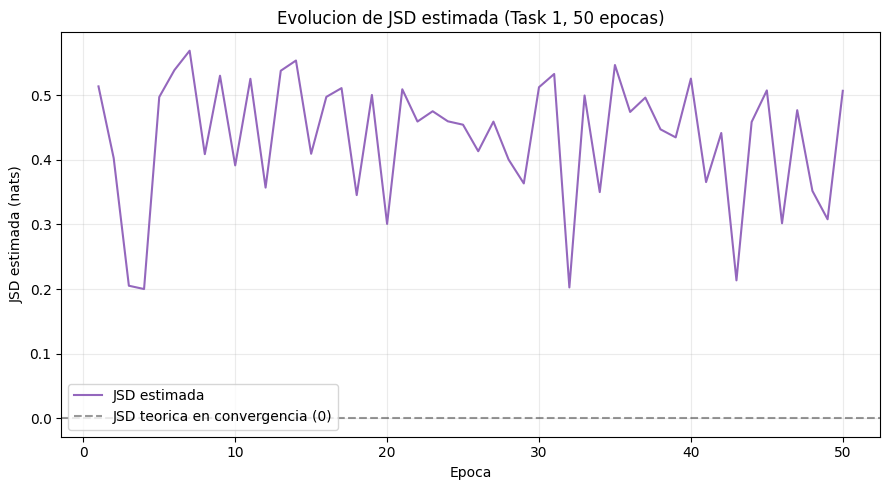

In [9]:
figure, axis = plt.subplots(figsize=(9, 5))
axis.plot(epochs_jsd, jsd_values, label='JSD estimada', color='tab:purple')
axis.axhline(0.0, color='black', linestyle='--', alpha=0.4, label='JSD teorica en convergencia (0)')
axis.set(xlabel='Epoca', ylabel='JSD estimada (nats)', title='Evolucion de JSD estimada (Task 1, 50 epocas)')
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'jsd_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(figure)

## 6. Analisis

El experimento de colapso (20 epocas, 5 pasos de D por 1 de G) muestra el patron
esperado: en las primeras 6 epocas `grad_norm_G` promedia 78.29, pero en cuanto
`loss_D` cae a ordenes de `1e-4`-`1e-5` (a partir de la epoca 7) la norma del
gradiente de G se desploma a un promedio de 0.22 en las 14 epocas restantes. La
media de `D(G(z))` final es 0.0000113, practicamente 0: D identifica con total
confianza que las salidas repetidas de G son falsas. La diversidad entre las 16
muestras finales (0.0449) es casi 9 veces menor que la del entrenamiento base de
Task 1 (0.4098), y la grilla `collapse_grid.png` confirma visualmente que las 16
salidas son practicamente indistinguibles entre si.

Para la estimacion de JSD sobre las 50 epocas del entrenamiento base de Task 1,
el valor oscila entre 0.20 y 0.57 nats sin tendencia a la baja (inicio: 0.5136,
mitad: 0.4543, final: 0.5067), lo cual es consistente con que D nunca perdio
la ventaja que ya se habia documentado en Task 1. Todos los valores caen dentro
del rango teorico valido \([0, \log 2]\), pero como el estimado subestima el
JSD real (el D usado nunca es el D optimo), el hecho de que ni siquiera ese
valor subestimado se acerque a 0 confirma que el juego adversarial no convergio
en las 50 epocas entrenadas.